In [18]:
import pandas as pd
df_10 = pd.read_csv('Preprocessed/15_10_test_preprocessed.csv')
df_25 = pd.read_csv('Preprocessed/15_25_test_preprocessed.csv')
df_train = pd.read_csv('Preprocessed/15_train_preprocessed.csv')

In [19]:
df_10 = df_10.sort_values(by=['serial_number', 'time'])
df_25 = df_25.sort_values(by=['serial_number', 'time'])
df_train = df_train.sort_values(by=['serial_number', 'time'])

df_10 = df_10.groupby('serial_number').head(10).groupby('serial_number').tail(1)
df_25 = df_25.groupby('serial_number').head(10).groupby('serial_number').tail(1)
df_train = df_train.groupby('serial_number').head(10).groupby('serial_number').tail(1)
df_10.shape, df_25.shape

((4345, 23), (4345, 23))

In [20]:
duration_10 = df_10['max_lifetime'] - df_10['time']
duration_25 = df_25['max_lifetime'] - df_25['time']
duration_train = df_train['max_lifetime'] - df_train['time']

<Axes: >

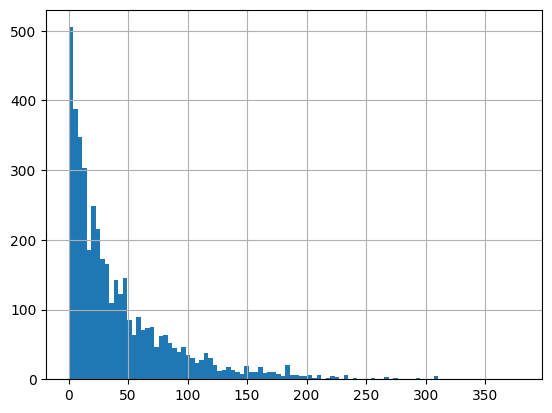

In [21]:
duration_10.hist(bins=100)

<Axes: >

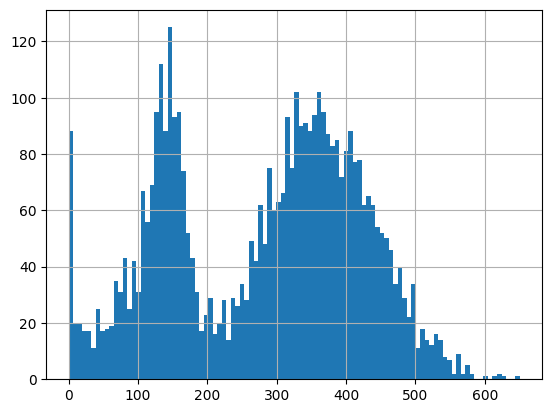

In [22]:
duration_25.hist(bins=100)


<Axes: >

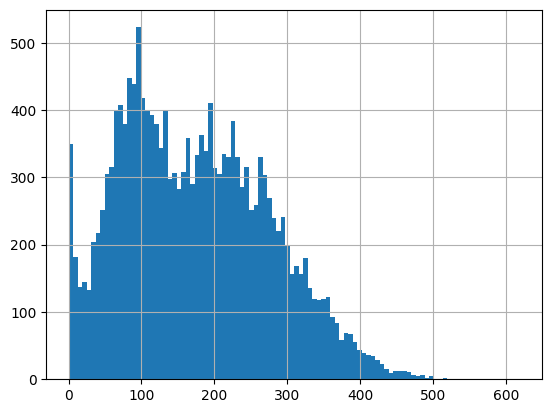

In [23]:
duration_train.hist(bins=100)

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# df = pd.read_csv('Backups/Backup_old_scaler/grid_search.csv')
df = pd.read_csv('Grid_Search/grid_search_cox.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'Grid_Search/grid_search_cox.csv'

In [ ]:
df

,train_samples,test_samples,method,l1_ratio,penalizer,ci_train_same_size,ci_train_max_size,ci_test,ibs_train_same_size,ibs_train_max_size,ibs_test,train_time,test_time,error,error_text,model_id
0,1,1.0,Cox,0.001,0.001000,0.5,0.5,0.5,0.182949,0.41354,0.186648,70.332331,0.239639,0,NaN,1
1,1,10.0,Cox,0.001,0.001000,0.5,0.5,0.5,0.182949,0.41354,0.383354,70.332331,2.022338,0,NaN,1
2,1,25.0,Cox,0.001,0.001000,0.5,0.5,0.5,0.182949,0.41354,0.406953,70.332331,4.821795,0,NaN,1
3,1,1.0,Cox,0.001,0.017783,0.5,0.5,0.5,0.182949,0.41354,0.186648,68.810870,0.291777,0,NaN,2
4,1,10.0,Cox,0.001,0.017783,0.5,0.5,0.5,0.182949,0.41354,0.383354,68.810870,2.046428,0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,50,NaN,Cox,100.000,0.001000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,FIT_ERROR$Matrix is singular.,221
439,50,NaN,Cox,100.000,0.017783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,FIT_ERROR$Matrix is singular.,222
440,50,NaN,Cox,100.000,0.316228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,FIT_ERROR$Matrix is singular.,223
441,50,NaN,Cox,100.000,5.623413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,FIT_ERROR$Matrix is singular.,224


In [ ]:
df[df['error'] == 1].groupby('train_samples')['error'].sum()

train_samples
40    6
50    6
Name: error, dtype: int64

In [ ]:
print(f'Всего было {df.shape[0]} запусков из которых {df[df["error"] == 0].shape[0]} завершились успешно')

Всего было 138 запусков из которых 126 завершились успешно


Результат с лучшими параметрами по каждой из метрик

In [ ]:
df[df['ci_train_same_size'] == df['ci_train_same_size'].max()]

,train_samples,test_samples,method,C,ci_train_same_size,ci_train_max_size,ci_test,ibs_train_same_size,ibs_train_max_size,ibs_test,train_time,test_time,error,error_text,model_id
48,5,1.0,LogReg_Classic,10.0,0.94526,0.944708,0.952653,0.084183,0.073668,0.109550,2.344235,1.112938,0,NaN,17
49,5,10.0,LogReg_Classic,10.0,0.94526,0.944708,0.947244,0.084183,0.073668,0.072108,2.344235,8.749329,0,NaN,17
50,5,25.0,LogReg_Classic,10.0,0.94526,0.944708,0.946935,0.084183,0.073668,0.068268,2.344235,21.362963,0,NaN,17


In [ ]:
df[df['ci_test'] == df['ci_test'].max()]

,train_samples,test_samples,method,C,ci_train_same_size,ci_train_max_size,ci_test,ibs_train_same_size,ibs_train_max_size,ibs_test,train_time,test_time,error,error_text,model_id
81,15,1.0,LogReg_Classic,1.0,0.944248,0.944093,0.953116,0.200481,0.194006,0.333624,6.894351,1.092913,0,NaN,28


In [ ]:
df[df['ibs_train_same_size'] == df['ibs_train_same_size'].min()]

,train_samples,test_samples,method,C,ci_train_same_size,ci_train_max_size,ci_test,ibs_train_same_size,ibs_train_max_size,ibs_test,train_time,test_time,error,error_text,model_id
87,15,1.0,LogReg_Classic,100.0,0.943952,0.944031,0.950456,0.055043,0.05331,0.069623,6.74699,1.220250,0,NaN,30
88,15,10.0,LogReg_Classic,100.0,0.943952,0.944031,0.945776,0.055043,0.05331,0.051096,6.74699,9.347887,0,NaN,30
89,15,25.0,LogReg_Classic,100.0,0.943952,0.944031,0.946126,0.055043,0.05331,0.049532,6.74699,23.158643,0,NaN,30


In [ ]:
df[(df['ibs_test'] == df['ibs_test'].min())]

,train_samples,test_samples,method,C,ci_train_same_size,ci_train_max_size,ci_test,ibs_train_same_size,ibs_train_max_size,ibs_test,train_time,test_time,error,error_text,model_id
35,2,25.0,LogReg_Classic,100.0,0.944757,0.945099,0.945971,0.06784,0.053129,0.048919,1.104943,23.596815,0,NaN,12


# Графики

In [ ]:
import matplotlib.pyplot as plt
def draw_pandas_plot(df, metric, ticks, test_samples=1, ax=None):
    # metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[metric].agg(['mean', 'min', 'max'])
    if not ax is None:
        ax.plot(metric_df)
        ax.set_yticks(ticks)
        ax.set_ylabel(metric)
        return 0
    return plt.plot(metric_df)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def draw_all_metrics_plots(df_full, metric, ticks, full_metrics_name=None, method=None):
    # === Константы оформления ===
    FIGSIZE = (14, 7)
    SUPTITLE_FONTSIZE = 22
    TITLE_FONTSIZE = 20
    LABEL_FONTSIZE = 20
    TICK_FONTSIZE = 20
    LEGEND_TITLE_FONTSIZE = 20
    LEGEND_FONTSIZE = 20

    if method is not None:
        df = df_full[df_full['method'] == method]
    else:
        df = df_full

    test_grid = sorted(df['test_samples'].dropna().unique())

    fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True, figsize=FIGSIZE)
    fig.suptitle(f'Метрика {full_metrics_name if full_metrics_name else metric}, модель {method}',
                 fontsize=SUPTITLE_FONTSIZE)

    # 1. train_max_size
    sns.lineplot(
        data=df,
        x='train_samples',
        y=f'{metric}_train_max_size',
        estimator='mean',
        errorbar=None,
        marker='o',
        ax=ax[0]
    )
    ax[0].set_yticks(ticks)
    ax[0].set_xlabel('n_train', fontsize=LABEL_FONTSIZE)
    ax[0].set_ylabel(metric.upper(), fontsize=LABEL_FONTSIZE)
    ax[0].set_title(f'С длиной цепочки максимального размера', fontsize=TITLE_FONTSIZE)
    ax[0].tick_params(axis='both', labelsize=TICK_FONTSIZE)

    # 2. test_samples (разные линии по test_samples)
    for test_samples in test_grid:
        sns.lineplot(
            data=df[df['test_samples'] == test_samples],
            x='train_samples',
            y=f'{metric}_test',
            estimator='mean',
            errorbar=None,
            marker='o',
            label=f'{test_samples}',
            ax=ax[1]
        )
    ax[1].set_xlabel('n_train', fontsize=LABEL_FONTSIZE)
    ax[1].set_yticks(ticks)
    ax[1].set_title(f'Длина цепочки в тестовой выборке', fontsize=TITLE_FONTSIZE)
    ax[1].tick_params(axis='both', labelsize=TICK_FONTSIZE)

    legend = ax[1].legend(title='Длина цепочки',
                          title_fontsize=LEGEND_TITLE_FONTSIZE,
                          fontsize=LEGEND_FONTSIZE)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(f'fig_{metric}.jpg')
    plt.show()


In [ ]:
import matplotlib
plt.rcParams["figure.figsize"] = (14,8)
plt.rcParams["font.family"] = "Times New Roman"
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 15

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=30)    # fontsize of the tick labels
plt.rc('ytick', labelsize=30)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
df = df[df['C'] >= 1]
draw_all_metrics_plots(df, 'ci', np.arange(0.93, 0.96, 0.005), full_metrics_name='Concordance Index', method = 'LogReg_Classic')


KeyError: 'C'

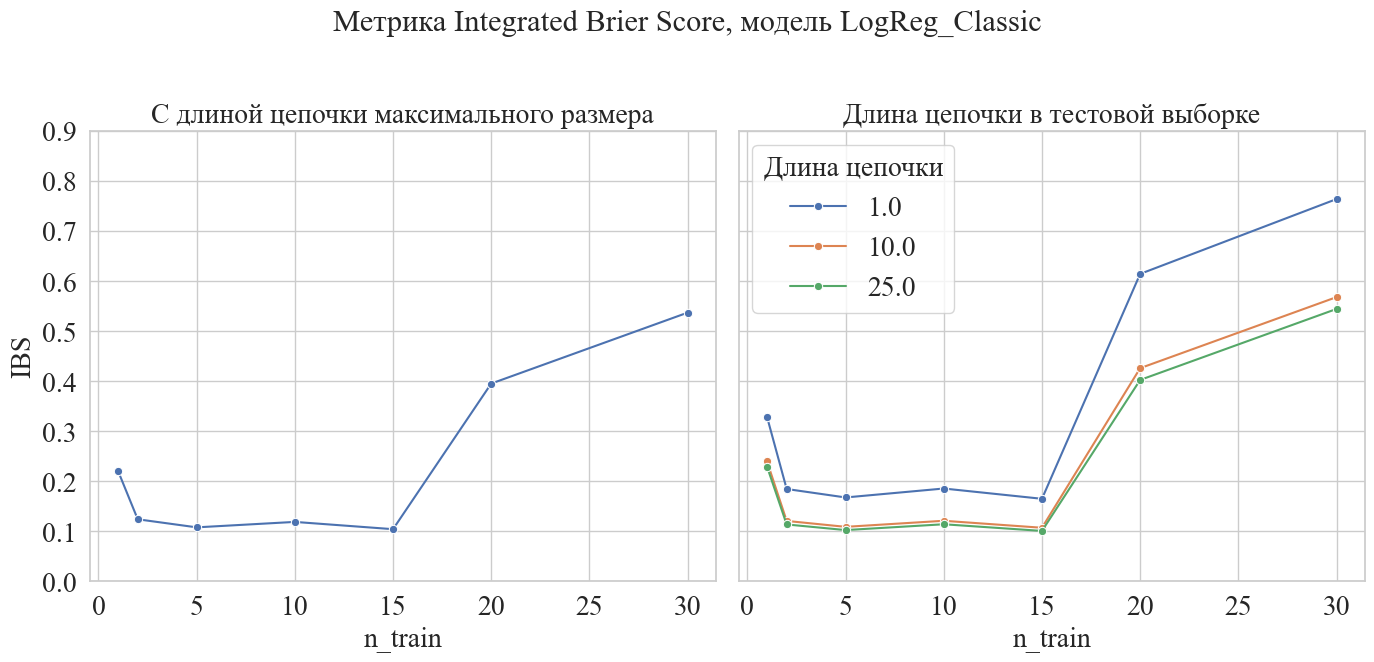

In [ ]:
draw_all_metrics_plots(df, 'ibs', np.arange(0, 1, 0.1), full_metrics_name='Integrated Brier Score'  , method='LogReg_Classic')

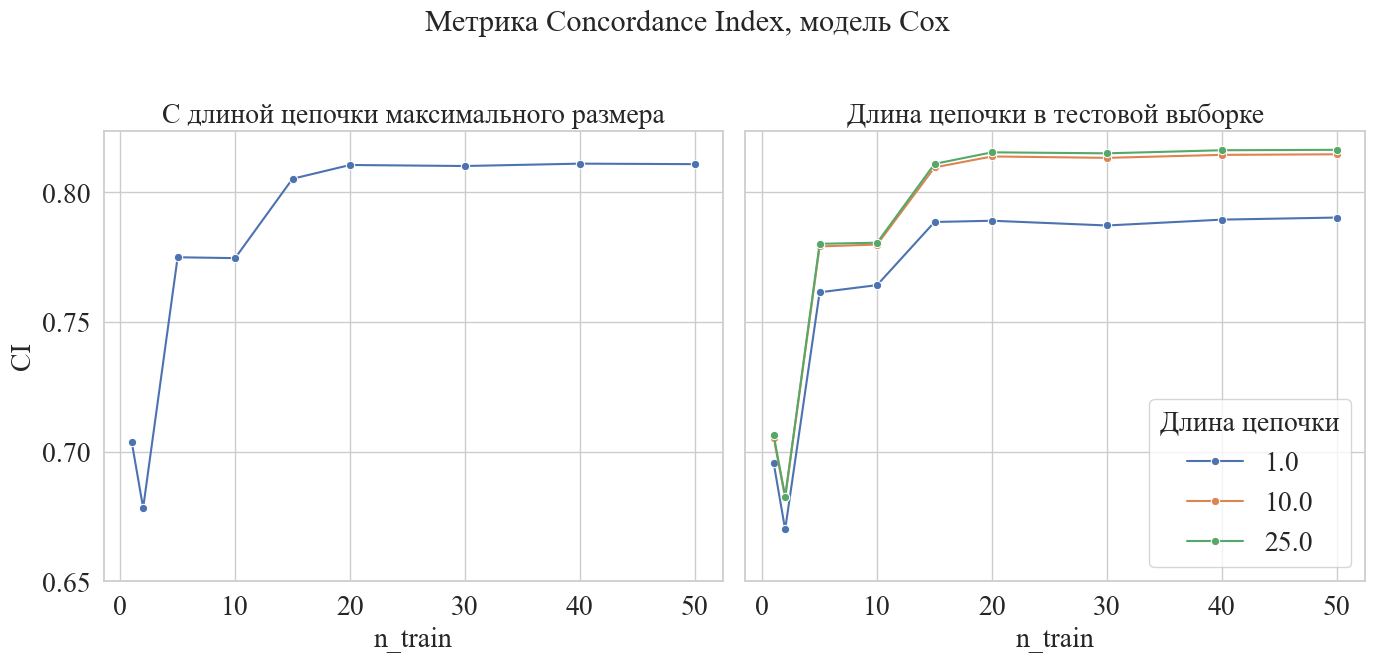

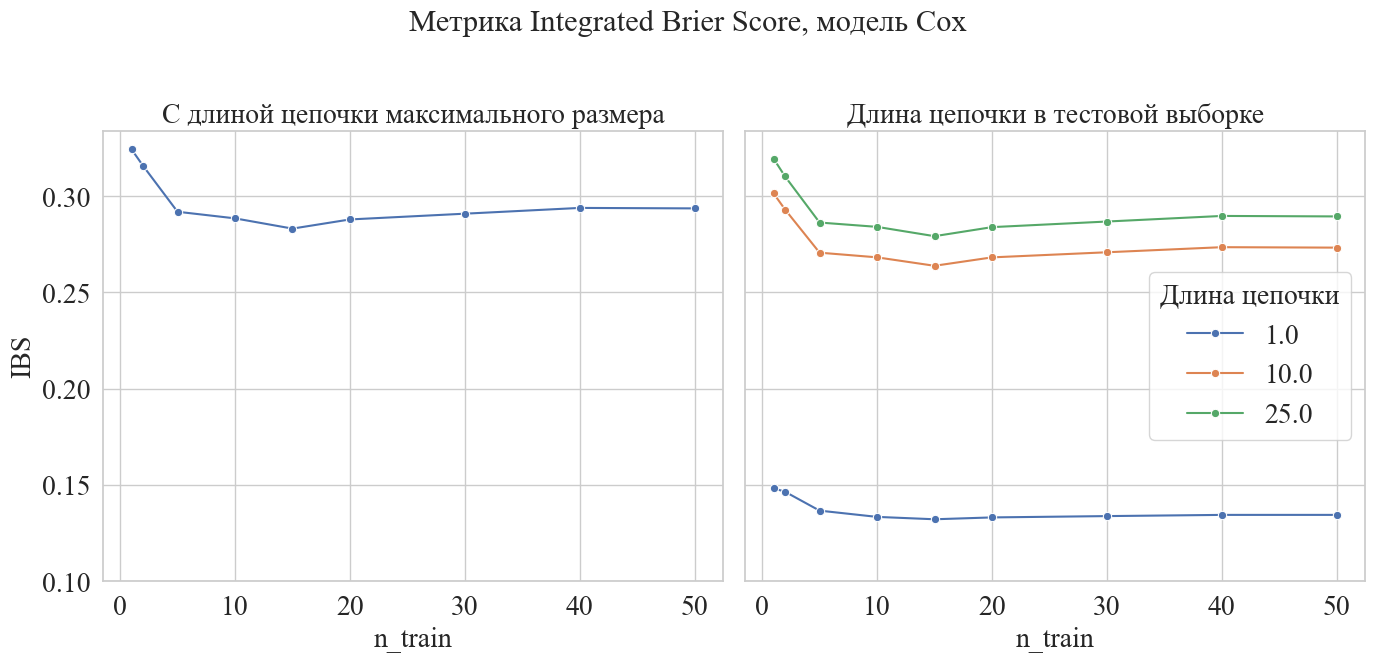

In [ ]:
draw_all_metrics_plots(df, 'ci', np.arange(0.65, 0.85, 0.05), full_metrics_name='Concordance Index', method = 'Cox')
draw_all_metrics_plots(df, 'ibs', np.arange(0.10, 0.35, 0.05), full_metrics_name='Integrated Brier Score', method='Cox')


In [ ]:
df_cox = pd.read_csv('grid_search_cox.csv')
draw_all_metrics_plots(df_cox, 'ci', np.arange(0.5, 1, 0.05), full_metrics_name='Concordance Index', method = 'Cox')
draw_all_metrics_plots(df_cox, 'ibs', np.arange(0, 1, 0.1), full_metrics_name='Integrated Brier Score', method='Cox')


KeyError: 'method'

In [ ]:
def draw_all_metrics_agg(df_full, metric, ticks, full_metrics_name=None, method = None):
    if not method is None:
        df = df_full[df_full['method'] == method]
    else:
        df = df_full
        
    test_grid = df['test_samples'].dropna().unique()
    test_grid_sz = len(test_grid)
    
    fig, ax = plt.subplots(1, 2 + test_grid_sz, sharey=True, tight_layout=True)
    fig.suptitle(f'Метрика {full_metrics_name if not full_metrics_name is None else metric}, модель {method}')

    metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean', 'min', 'max'])
    ax[0].plot(metric_df, marker='.')
    ax[0].set_yticks(ticks)
    ax[0].set_xlabel('n_train')
    ax[0].set_title(f'С длиной цепочки n_train')

    ax[0].grid()

    metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean', 'min', 'max'])
    ax[1].plot(metric_df, marker='.')
    ax[1].set_yticks(ticks)
    ax[1].set_title(f'C длиной цепочки максимального размера')
    ax[1].set_xlabel('n_train')
    ax[1].grid()
    
    for i, test_samples in enumerate(test_grid):
        metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean', 'min', 'max'])
        ax[i + 2].plot(metric_df, marker='.')
        ax[i + 2].set_xlabel('n_train')
        ax[i + 2].grid()
        
        ax[i + 2].set_yticks(ticks)
        ax[i + 2].set_title(f'Длина цепочки в тестовой выборке: {test_samples}')
    fig.savefig(f'fig_{metric}.jpg')

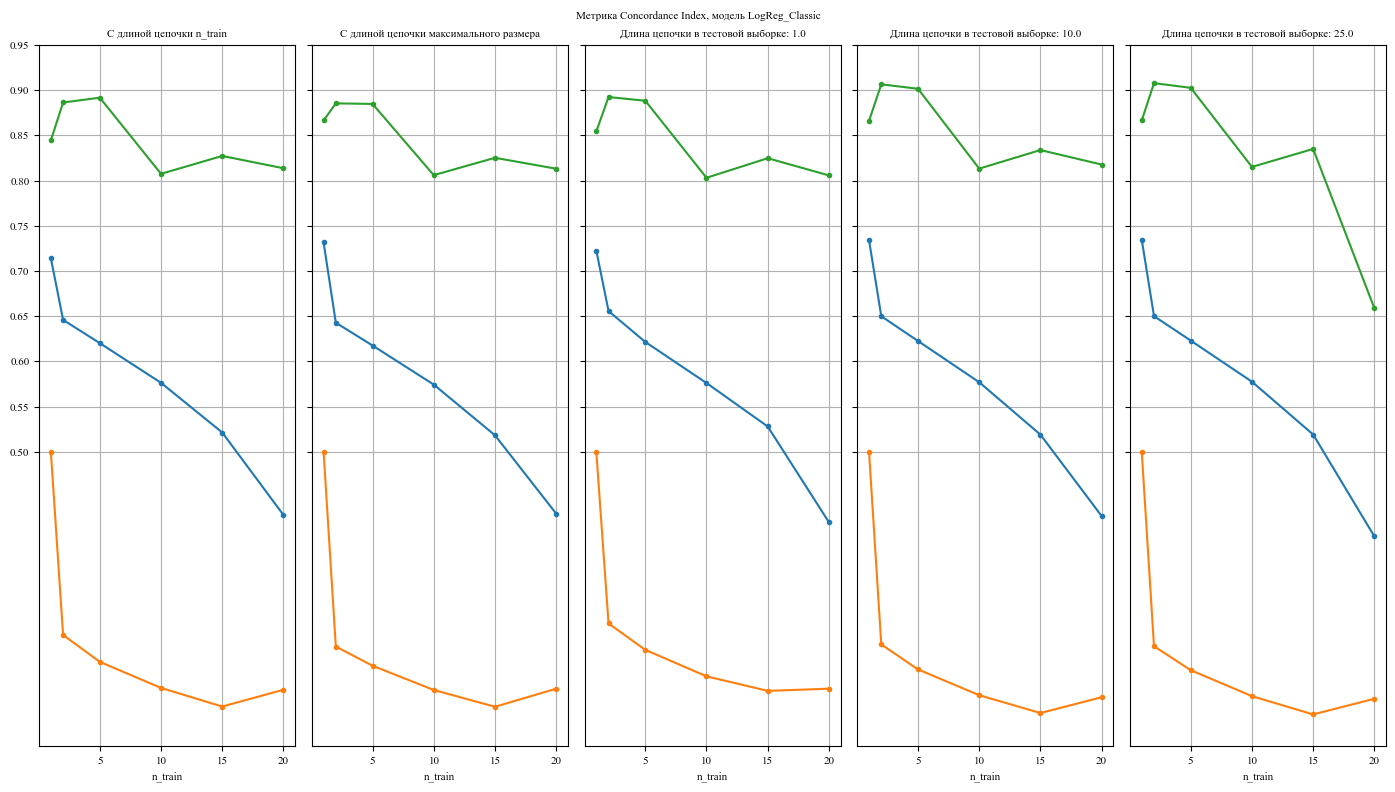

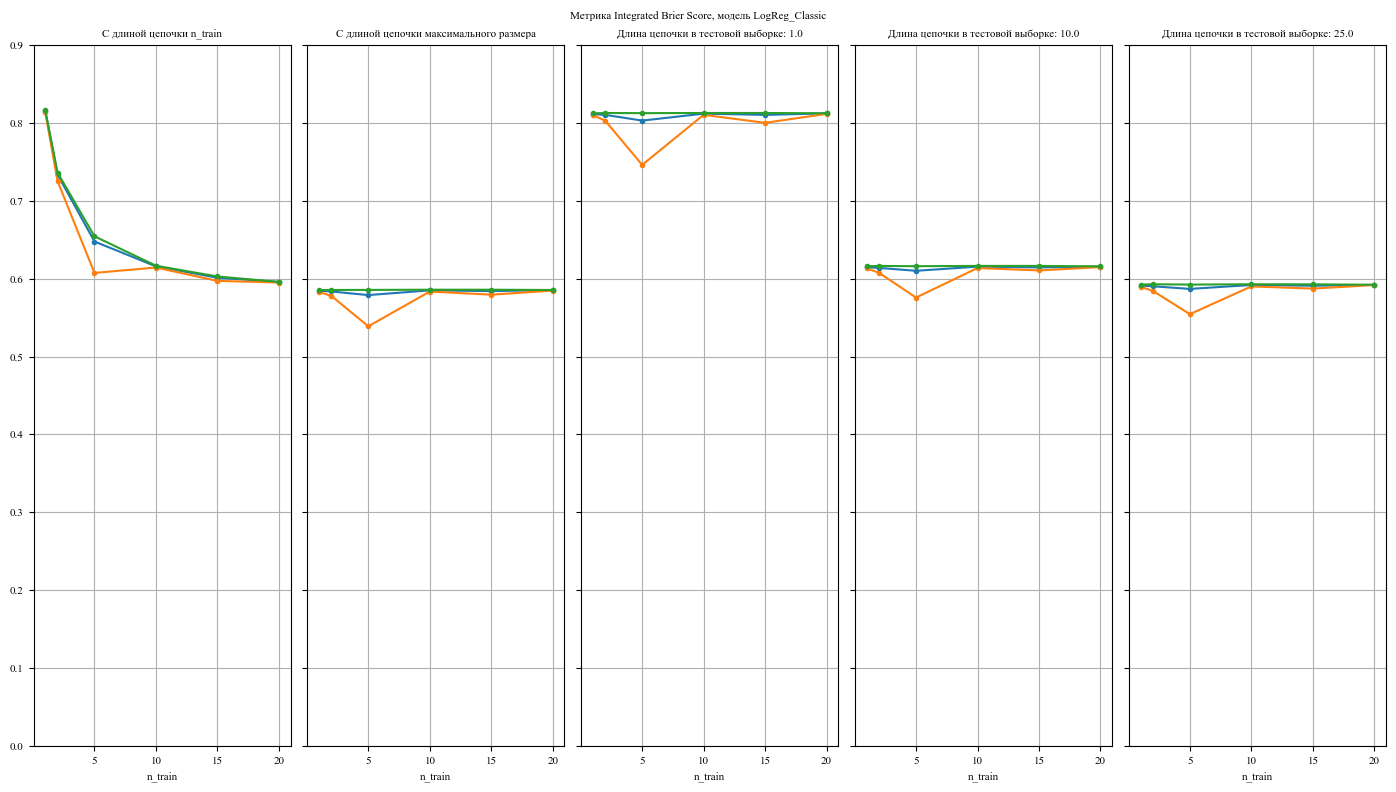

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (14,8)
plt.rcParams["font.family"] = "Times New Roman"
SMALL_SIZE = 6
MEDIUM_SIZE = 7
BIGGER_SIZE = 8

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
df_logreg = pd.read_csv('grid_search.csv')
draw_all_metrics_agg(df_logreg, 'ci', np.arange(0.5, 1, 0.05), full_metrics_name='Concordance Index', method = 'LogReg_Classic')
draw_all_metrics_agg(df_logreg, 'ibs', np.arange(0, 1, 0.1), full_metrics_name='Integrated Brier Score', method='LogReg_Classic')


In [ ]:
# from modules.constants import TEST_GRID

# for test_samples in TEST_GRID:
#     fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
#     fig.suptitle(f'test_samples={test_samples}')
#     draw_pandas_plot(df, 'ci_train_same_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples, ax = ax[0])
#     draw_pandas_plot(df, 'ci_train_max_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax = ax[1])
#     draw_pandas_plot(df, 'ci_test', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax=ax[2])
    
# for test_samples in TEST_GRID:
#     fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
#     fig.suptitle(f'test_samples={test_samples}')
#     draw_pandas_plot(df, 'ibs_train_same_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples, ax = ax[0])
#     draw_pandas_plot(df, 'ibs_train_max_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax = ax[1])
#     draw_pandas_plot(df, 'ibs_test', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax=ax[2])

: 

: 

In [ ]:
from modules.constants import TEST_GRID
for test_samples in TEST_GRID:
    fig, ax = plt.subplots(1, sharey=True, tight_layout=True)
    fig.suptitle(f'test_samples={test_samples}')
    draw_pandas_plot(df, 'test_time', np.arange(0, 1250, 125), test_samples=test_samples, ax = ax)

: 

: 

In [ ]:
metric_df = df[df['test_samples'] == 1].groupby('train_samples')['train_time'].agg(['median'])
plt.plot(metric_df, marker='.')
plt.title('Время обучения')
plt.xlabel('Число наблюдений в цепочке')
plt.ylabel('Время обучения, с')

: 

: 

In [ ]:
from modules.constants import TEST_GRID
fig, ax = plt.subplots(1, sharey=True, tight_layout=True)
fig.suptitle(f'Train time')
draw_pandas_plot(df, 'train_time', np.arange(0, 200, 50), test_samples=1, ax = ax)

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_pandas_plot(df, 'ci_train_same_size', np.arange(0.0, 1.1, 0.05), ax = ax[0])
draw_pandas_plot(df, 'ci_train_max_size', np.arange(0.0, 1.1, 0.05), ax = ax[1])
draw_pandas_plot(df, 'ci_test', np.arange(0.0, 1.1, 0.05), ax=ax[2])

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_pandas_plot(df, 'ibs_train_same_size', np.arange(0.1, 0.3, 0.05), ax=ax[0])
draw_pandas_plot(df, 'ibs_train_max_size', np.arange(0.1, 0.3, 0.05), ax=ax[1])
draw_pandas_plot(df, 'ibs_test', np.arange(0.1, 0.3, 0.05), ax=ax[2])


: 

: 

In [ ]:
df_top = df.sort_values(by='ibs_train_same_size', ascending=True).groupby('train_samples').head(7)

: 

: 

In [ ]:
def draw_mean_plot(df, metric, ticks, test_samples=1, ax=None):
    metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[metric].agg(['mean'])
    if not ax is None:
        ax.plot(metric_df)
        ax.set_yticks(ticks)
        ax.set_ylabel(metric)
        return 0
    return plt.plot(metric_df)

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_mean_plot(df_top, 'ci_train_same_size', np.arange(0.7, 1, 0.05), ax=ax[0])
draw_mean_plot(df_top, 'ci_train_max_size', np.arange(0.7, 1, 0.05), ax=ax[1])
draw_mean_plot(df_top, 'ci_test', np.arange(0.7, 1, 0.05), ax=ax[2])

: 

: 

In [ ]:
fig, ax = plt.subplots(1, sharey=True, tight_layout=True)
draw_mean_plot(df_top, 'train_time', np.arange(0, 1000, 100), ax=ax)

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_mean_plot(df_top, 'ibs_train_same_size', np.arange(0.1, 0.50, 0.05), ax=ax[0])
draw_mean_plot(df_top, 'ibs_train_max_size', np.arange(0.1, 0.50, 0.05), ax=ax[1])
draw_mean_plot(df_top, 'ibs_test', np.arange(0.1, 0.50, 0.05), ax=ax[2])a

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=10')
draw_mean_plot(df_top, 'ibs_train_same_size', np.arange(0.1, 0.50, 0.05),test_samples=10, ax=ax[0])
draw_mean_plot(df_top, 'ibs_train_max_size', np.arange(0.1, 0.50, 0.05), test_samples=10,ax=ax[1])
draw_mean_plot(df_top, 'ibs_test', np.arange(0.1, 0.50, 0.05), test_samples=10,ax=ax[2])

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True)
fig.suptitle('test_samples=25')
draw_pandas_plot(df, 'ci_train', np.arange(0.4, 1.1, 0.05), test_samples=25, ax = ax[0])
draw_pandas_plot(df, 'ci_test', np.arange(0.4, 1.1, 0.05), test_samples=25, ax=ax[1])

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True)
fig.suptitle('test_samples=25')
draw_pandas_plot(df, 'ibs_train', np.arange(0.1, 1.1, 0.05), test_samples=25, ax = ax[0])
draw_pandas_plot(df, 'ibs_test', np.arange(0.1, 1.1, 0.05), test_samples=25, ax=ax[1])

: 

: 

In [ ]:
# import matplotlib.pyplot as plt
# def draw_all_metrics_plots(df, metric, ticks, full_metrics_name=None):
#     test_grid = df['test_samples'].dropna().unique()
#     test_grid_sz = len(test_grid)
    
#     fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True)
#     fig.suptitle(f'Метрика {full_metrics_name if not full_metrics_name is None else metric}')

#     metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean', 'min', 'max'])
#     metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean'])
#     ax[0].plot(metric_df, marker='.')
#     ax[0].set_yticks(ticks)
#     ax[0].set_xlabel('n_train')
#     # ax[0].set_title(f'С длиной цепочки n_train')

#     ax[0].grid()

#     metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean', 'min', 'max'])
#     metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean'])
#     ax[0].plot(metric_df, marker='.')
#     ax[0].set_yticks(ticks)
#     ax[0].set_title(f'C длиной цепочки максимального размера')
#     ax[0].set_xlabel('n_train')
#     ax[0].grid()
    
#     for i, test_samples in enumerate(test_grid):
#         metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean', 'min', 'max'])
#         metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean'])
#         ax[1].plot(metric_df, marker='.')
#         ax[1].set_xlabel('n_train')
#         ax[1].grid()
        
#         ax[1].set_yticks(ticks)
#     ax[1].set_title(f'Длина цепочки в тестовой выборке: {test_samples}')
#     ax[1].legend([1, 10, 25], title='Длина цепочки')
#     fig.savefig(f'fig_{metric}.jpg')

: 

: 

# Агрегация

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Agg_30_30_9.csv', index_col=False)

In [ ]:
df

,train_samples,agg_samples,method,agg_method,agg_weight,ci_train,ibs_train,model_id
0,30,1,Cox,n_dist,0.1,0.791950,0.215078,152
1,30,1,Cox,n_dist,0.9,0.791950,0.215078,152
2,30,1,Cox,t_dist,1.0,0.791950,0.215078,152
3,30,1,Cox,t_dist,100.0,0.791950,0.215078,152
4,30,1,Cox,prob_dist,0.0,0.791950,0.215078,152
...,...,...,...,...,...,...,...,...
751,30,9,Cox,t_dist,1.0,0.743116,0.268317,165
752,30,9,Cox,t_dist,100.0,0.172779,0.230769,165
753,30,9,Cox,prob_dist,0.0,0.160920,0.219713,165
754,30,9,Cox,geom,0.1,0.155199,0.207362,165


In [ ]:
# import pickle 
# from torch.utils.data import DataLoader
# from disk_analyzer.models.Dataset import DiskDataset
# from disk_analyzer.stages.model_scoring import ModelScorer
# from Agg import TIMES

# with open('models/11_LogReg_model.pkl', 'rb') as f:
#     model = pickle.load(f)

# dl_train = DataLoader(
#     dataset=DiskDataset(mode='score', file_paths=['Preprocessed/30_train_preprocessed.csv']),
#     batch_size= 100000,
# )
# X_pred, X_gt = model.predict(dl_train, times = TIMES)
# scorer = ModelScorer()
# ci, ibs = scorer.get_ci_and_ibs(model, X_pred, X_gt, times=TIMES)
# print(ci, ibs)

  0%|          | 0/6 [00:00<?, ?it/s]

: 

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def draw_new_plot(df, method=None):
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    plot_df = df.copy()
    
    if method is not None:
        plot_df = plot_df[plot_df['method'] == method]

    plot_df['agg_label'] = plot_df['agg_method'].astype(str) + ' / w=' + plot_df['agg_weight'].astype(str)
    
    y_formatter = ScalarFormatter(useOffset=False)
    y_formatter.set_scientific(False)
    
    metrics = ['ci_train', 'ibs_train']
    
    for i, metric in enumerate(metrics):
        sns.lineplot(
            data=plot_df,
            x='agg_samples',
            y=metric,
            hue='agg_label',
            estimator='min',
            errorbar=None,
            markers=True,
            markersize=8,
            linewidth=2.5,
            ax=ax[i]
        )
        
        ax[i].yaxis.set_major_formatter(y_formatter)
        ax[i].ticklabel_format(axis='y', style='plain', useOffset=False)
        ax[i].get_yaxis().set_major_formatter(
            plt.FuncFormatter(lambda x, loc: f"{x:.6f}")
        )
        
        ax[i].set_title(
            f"{method if method else ''} - {metric}",
            fontsize=14
        )
        ax[i].set_xlabel("Number of Samples", fontsize=12)
        ax[i].set_ylabel(metric.upper(), fontsize=12)
        ax[i].tick_params(labelsize=10)
        ax[i].set_xticks(sorted(plot_df['agg_samples'].unique()))
        
        legend = ax[i].legend(title='Agg Method / Weight', title_fontsize=10, fontsize=12)
    
    plt.tight_layout()
    sns.despine()
    plt.show()


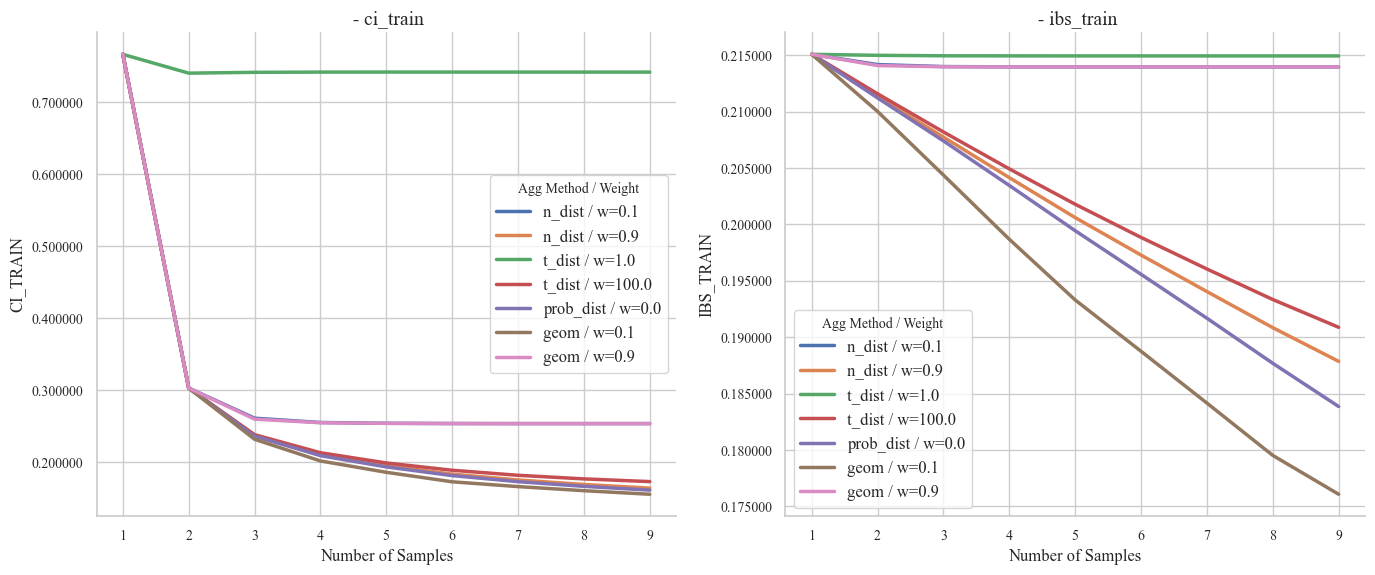

In [ ]:
aggregators_dict = {
    "n_dist": {
        "0.1": None,
        "0.9": None
    },
    "t_dist": {
        "1": None,
        "100":None 
    },
    "prob_dist": {
        "0": None,
    },
    "geom": {
        "0.1": None,
        "0.9": None
    }
}
# METHODS = ['LogReg', 'NN']
METHODS = ['Cox']
df_model = df[df['model_id'] == 105]
df_model=df
for method in METHODS:
    draw_new_plot(df_model)

# Агрегация Кокса